# 第14讲：数据可视化基础

## 课程简介

数据可视化是数据分析的重要组成部分。  
它既可以帮助我们在数据清洗阶段发现异常值和分布特征，也可以用于展示分析结论。

本讲主要介绍 Python 数据分析中常见的可视化工具：

- Matplotlib 的 Figure、Axes 和 subplot
- 线图、柱状图、直方图、密度图、散点图
- 坐标轴、标题、刻度、图例和注解
- 使用 Pandas 快速绘图
- 使用 Seaborn 绘制统计图形
- 使用分面图展示多维分类数据

本讲的重点不是记住所有参数，而是理解“图形由哪些元素组成”，以及如何选择合适的图表表达数据。


## 1 导入库与准备示例数据

<div class="alert alert-success">

**环境提示**

本讲使用 Matplotlib、Pandas 和 Seaborn。  
如果缺少 Seaborn，请先安装：

```bash
pip install seaborn
```

</div>
运行下方代码即可安装

In [ ]:
!pip install seaborn

为了保证课件可以独立运行，本节会自动创建绘图示例数据，包括：

- `examples/spx.csv`：模拟股票指数数据
- `examples/tips.csv`：模拟小费数据
- `examples/macrodata.csv`：模拟宏观经济数据


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

%matplotlib inline

np.random.seed(12345)

pd.options.display.max_rows = 20
pd.options.display.max_columns = 20
pd.options.display.max_colwidth = 80
np.set_printoptions(precision=4, suppress=True)

example_dir = Path("examples")
example_dir.mkdir(exist_ok=True)

# 1. 模拟股票指数数据
dates = pd.date_range("1990-01-01", "2012-12-31", freq="B")
spx_values = 1000 + np.random.normal(0.15, 12, len(dates)).cumsum()
spx = pd.DataFrame({"SPX": spx_values}, index=dates)
spx.to_csv(example_dir / "spx.csv")

# 2. 模拟小费数据
n = 300
days = np.random.choice(["Thur", "Fri", "Sat", "Sun"], size=n, p=[0.25, 0.15, 0.35, 0.25])
times = np.where(np.isin(days, ["Thur", "Fri"]), 
                 np.random.choice(["Lunch", "Dinner"], size=n, p=[0.65, 0.35]), 
                 "Dinner")
sizes = np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.45, 0.22, 0.18, 0.07, 0.03])
total_bill = np.round(np.random.gamma(shape=2.2, scale=10, size=n) + sizes * 3, 2)
tip_rate = np.clip(np.random.normal(0.16, 0.04, size=n), 0.05, 0.35)
tip = np.round(total_bill * tip_rate, 2)
smoker = np.random.choice(["Yes", "No"], size=n, p=[0.35, 0.65])

tips = pd.DataFrame({
    "total_bill": total_bill,
    "tip": tip,
    "smoker": smoker,
    "day": days,
    "time": times,
    "size": sizes
})
tips.to_csv(example_dir / "tips.csv", index=False)

# 3. 模拟宏观经济数据
periods = pd.period_range("1959Q1", periods=120, freq="Q")
macro = pd.DataFrame({
    "year": periods.year,
    "quarter": periods.quarter,
    "cpi": 50 + np.linspace(0, 160, len(periods)) + np.random.normal(0, 1.5, len(periods)).cumsum(),
    "m1": 120 + np.linspace(0, 900, len(periods)) + np.random.normal(0, 4, len(periods)).cumsum(),
    "tbilrate": np.clip(np.random.normal(4.0, 1.1, len(periods)), 0.1, None),
    "unemp": np.clip(np.random.normal(6.0, 1.2, len(periods)), 2.0, None),
    "realgdp": 2500 + np.linspace(0, 7000, len(periods)) + np.random.normal(0, 100, len(periods)).cumsum(),
    "infl": np.clip(np.random.normal(3.0, 1.0, len(periods)), 0.1, None)
})
macro.to_csv(example_dir / "macrodata.csv", index=False)

print("示例数据已准备完成：", example_dir.resolve())

示例数据已准备完成： /Users/taohe/Dropbox/Work/Courses/python_course/examples


### <font color='limegreen'><b>技巧与提示</b></font>

Matplotlib 中最核心的两个对象是：

- `Figure`：整张画布
- `Axes`：具体的一张子图，也就是实际绘图区域

初学时可以使用 `plt.plot()` 这类快捷接口；  
当图表变复杂时，更推荐使用 `fig, ax = plt.subplots()` 的面向对象写法。


## 2 Matplotlib 基础

信息可视化，也就是绘图，是数据分析中非常重要的一环。  
本节主要学习 Matplotlib 的基本概念和常用操作。

Matplotlib 是 Python 中经典的绘图库。很多高级绘图库，例如 Pandas 绘图和 Seaborn，底层也基于 Matplotlib。


In [2]:
data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

下面创建一个最简单的线图。

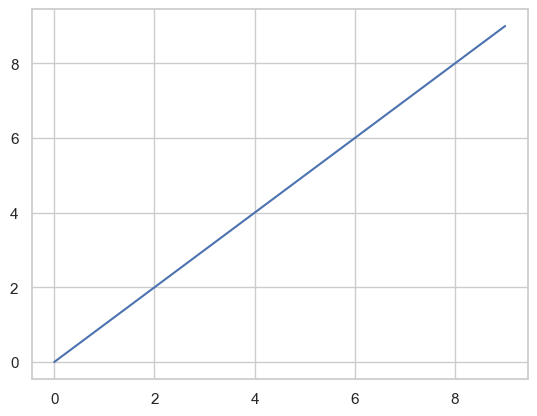

In [3]:
plt.plot(data)

### 2.1 Figure 和 Subplot

Matplotlib 的图形都位于 `Figure` 对象中。  
可以使用 `plt.figure()` 创建一个新的 Figure。


In [4]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

空的 Figure 本身不会显示任何数据。  
通常需要通过 `add_subplot()` 或 `plt.subplots()` 创建一个或多个绘图区。


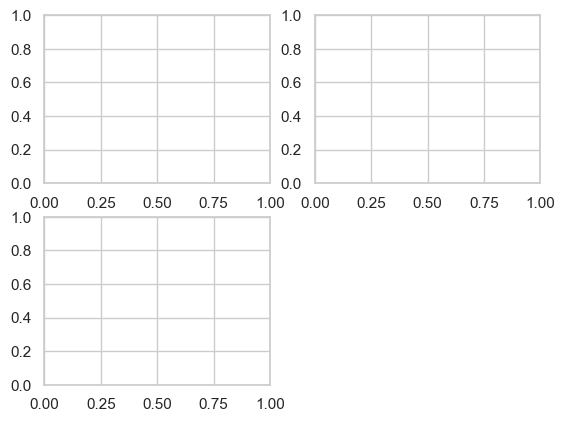

In [5]:
# By default, the inline backend closes a figure after a cell has been fully executed.
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

如果执行一条绘图命令，Matplotlib 会把图形绘制到当前激活的 subplot 上。  
下面的例子创建了一个 2×2 的子图布局，并分别绘制直方图、散点图和线图。


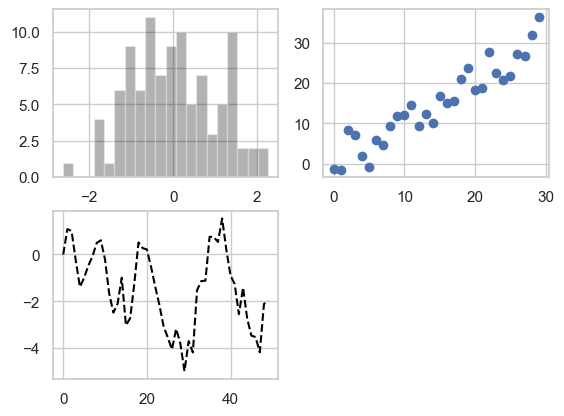

In [6]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

`"k--"` 是一种格式字符串，表示黑色虚线。  
不过在较复杂的代码中，更推荐显式写出 `color`、`linestyle`、`marker` 等参数。


创建 subplot 网格时，更常用的方法是 `plt.subplots()`。  
它会同时创建 Figure 和一组 Axes 对象。


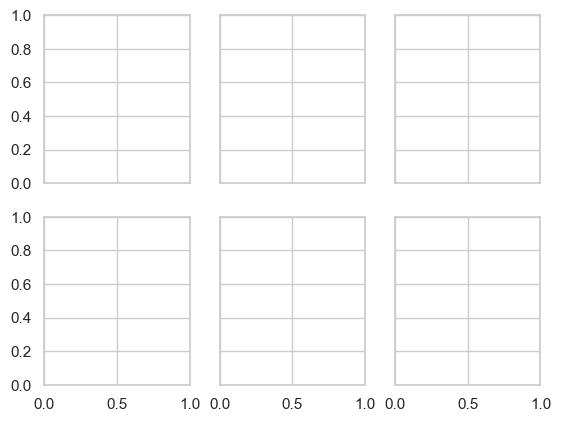

In [7]:
fig, axes = plt.subplots(2, 3, sharex=True, sharey=True)

In [8]:
axes

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

`axes` 可以像二维数组一样索引，例如 `axes[0, 1]`。  
`sharex` 和 `sharey` 可以让多个子图共享坐标轴，便于比较。

### `plt.subplots()` 常用参数

| 参数 | 说明 |
|---|---|
| `nrows`, `ncols` | 子图行数和列数 |
| `sharex`, `sharey` | 是否共享 X 轴或 Y 轴 |
| `figsize` | Figure 尺寸 |
| `squeeze` | 是否压缩返回的 Axes 维度 |


### 2.2 调整 subplot 周围的间距

默认情况下，Matplotlib 会在子图之间留出一定空白。  
可以使用 `fig.subplots_adjust()` 调整边距和子图间距。


In [9]:
fig.subplots_adjust(left=None, bottom=None, right=None, top=None,
                    wspace=None, hspace=None)

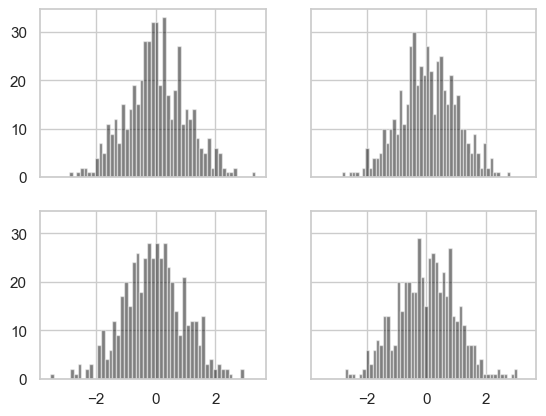

In [10]:
# 修改前
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50,
                        color="black", alpha=0.5)

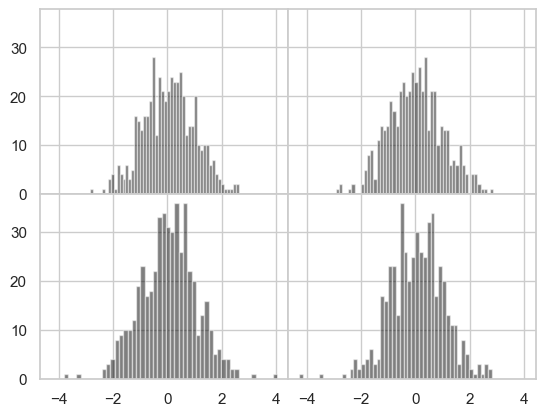

In [11]:
# 修改后
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50,
                        color="black", alpha=0.5)
fig.subplots_adjust(wspace=0, hspace=0)

### 2.3 颜色、标记和线型

`plot()` 可以接收颜色、线型和标记参数。  
例如，`"g--"` 表示绿色虚线。

在自己初始的项目代码中，更推荐使用显式参数：

```python
ax.plot(x, y, color="green", linestyle="--", marker="o")
```

这种写法更清晰，也更容易维护。


线图可以使用标记强调真实数据点。  
因为线会在数据点之间连接，添加标记可以帮助我们看清每个观测点的位置。


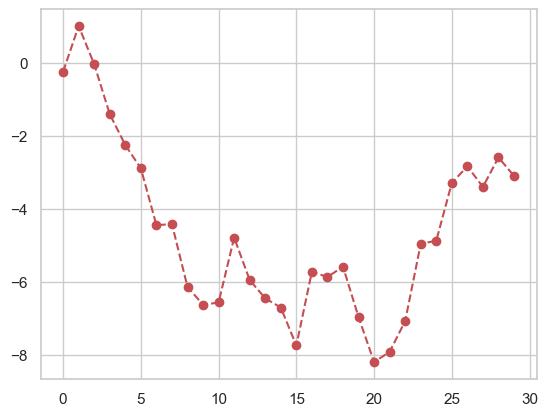

In [12]:
plt.plot(np.random.standard_normal(30).cumsum(), 'ro--');

同样的图形也可以用更明确的参数写法实现。

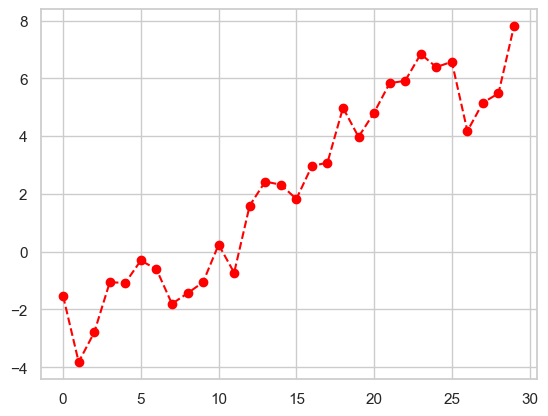

In [13]:
plt.plot(np.random.standard_normal(30).cumsum(), color='red', linestyle='dashed', marker='o');

线图中的点默认按线性方式连接。  
可以使用 `drawstyle` 参数改变连接方式。


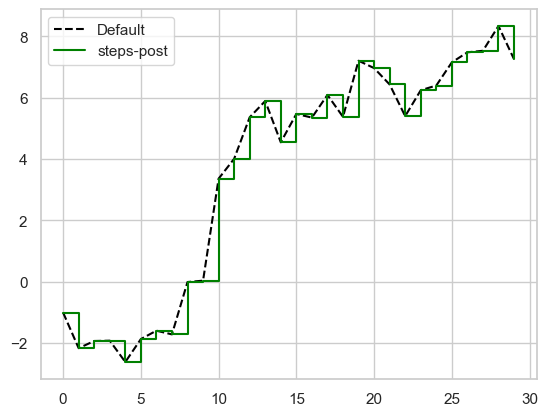

In [14]:
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()
ax.plot(data, color="black", linestyle="dashed", label="Default");
ax.plot(data, color="green", linestyle="-", drawstyle="steps-post", label="steps-post");
ax.legend()

Matplotlib 的绘图函数会返回图形元素对象。  
在 notebook 中，这些对象有时会显示出来；可以在代码末尾加分号 `;` 隐藏它们。


### 2.4 刻度、标签和图例

图表不仅包含数据本身，还包含标题、坐标轴标签、刻度、图例等说明元素。  
这些元素决定了图表是否易读。

常用方法包括：

- `set_title()`：设置标题
- `set_xlabel()` / `set_ylabel()`：设置坐标轴标签
- `set_xticks()` / `set_yticks()`：设置刻度位置
- `set_xticklabels()` / `set_yticklabels()`：设置刻度标签
- `legend()`：显示图例


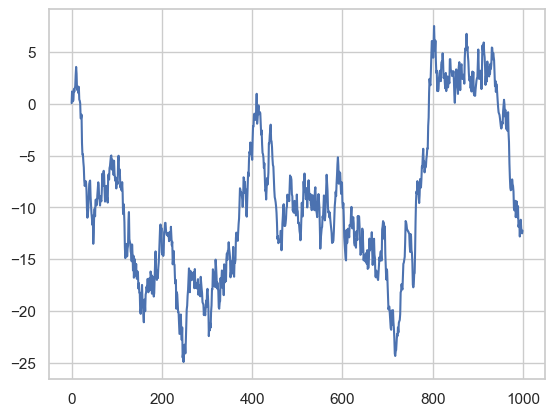

In [15]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum());

下面通过 `set_xticks()` 和 `set_xticklabels()` 修改 X 轴刻度。  
`rotation` 可以旋转刻度标签，避免标签重叠。


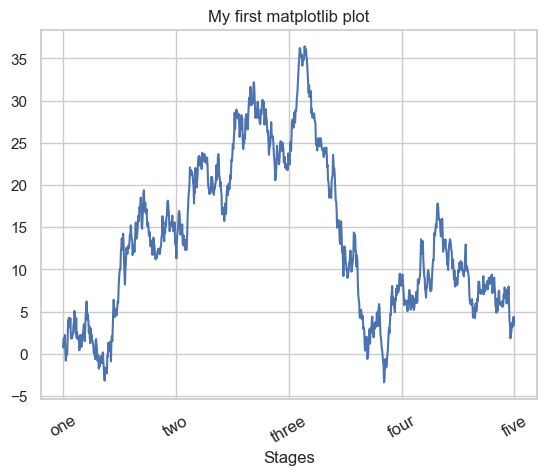

In [16]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())

ax.set_xticks([0, 250, 500, 750, 1000])
ax.set_xticklabels(["one", "two", "three", "four", "five"], rotation=30, fontsize=12)
ax.set_xlabel("Stages")
ax.set_title("My first matplotlib plot");

也可以使用 `ax.set(**props)` 一次性设置多个图表属性。

In [17]:
props = {
    'title': 'My first matplotlib plot',
    'xlabel': 'Stages'
}
ax.set(**props)

[Text(0.5, 1.0, 'My first matplotlib plot'),
 Text(0.5, 25.078125000000007, 'Stages')]

### 2.5 添加图例

图例用于说明不同线条或图形元素代表什么。  
最简单的方式是在绘图时设置 `label`，然后调用 `ax.legend()`。


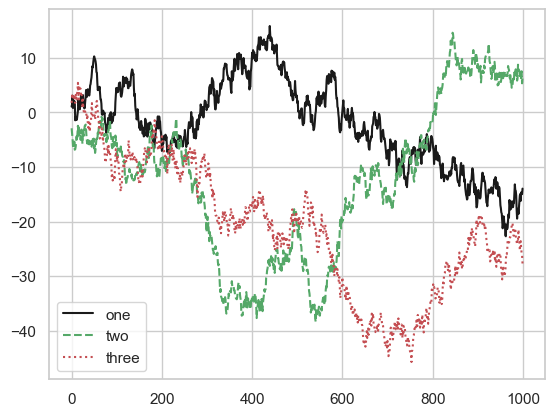

In [18]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum(), color="k", label="one");
ax.plot(np.random.standard_normal(1000).cumsum(), color="g", linestyle="dashed",
        label="two");
ax.plot(np.random.standard_normal(1000).cumsum(), color="r", linestyle="dotted",
        label="three");

# 然后通过调用ax.legend()或plt.legend()来自动创建图例
ax.legend();

`legend()` 的 `loc` 参数可以控制图例位置。  
常用设置是 `loc="best"`，让 Matplotlib 自动选择合适位置。

### 2.6 注解以及在 subplot 上绘图

注解（annotation）可以帮助我们突出重要事件、异常值或关键转折点。  
Matplotlib 中可以使用 `ax.annotate()` 添加文字和箭头。


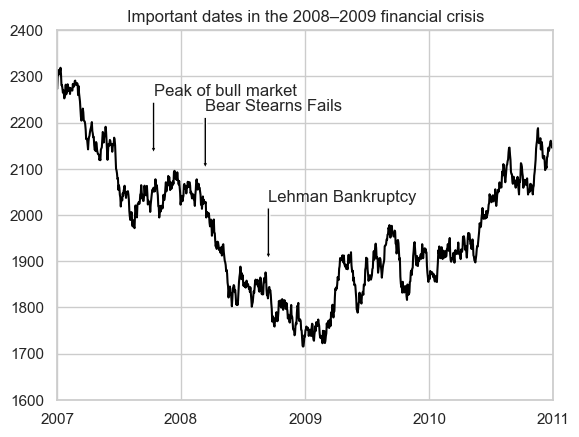

In [19]:
from datetime import datetime

fig, ax = plt.subplots()

data = pd.read_csv("examples/spx.csv", index_col=0, parse_dates=True)
spx = data["SPX"]

spx.plot(ax=ax, color="black")

crisis_data = [
    (datetime(2007, 10, 11), "Peak of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy")
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                headlength=4),
                horizontalalignment="left", verticalalignment="top")

# Zoom in on 2007-2010
ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([1600, 2400])

ax.set_title("Important dates in the 2008–2009 financial crisis");

除了线、点、柱等标准图形，Matplotlib 还可以添加图形对象，例如矩形、圆形和多边形。  
这些对象称为 patch，可以通过 `ax.add_patch()` 添加到图中。


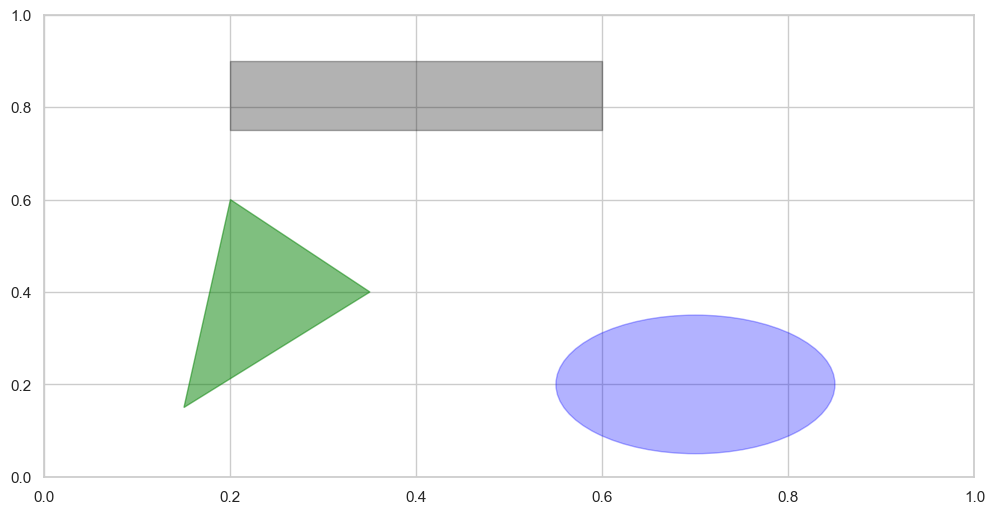

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color="black", alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color="green", alpha=0.5)
ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon);

### 2.7 将图表保存到文件

可以使用 `plt.savefig()` 或 `fig.savefig()` 保存图表。  
文件类型会根据扩展名自动推断，例如 `.png`、`.pdf`、`.svg`。

常用参数包括：

| 参数 | 说明 |
|---|---|
| `dpi` | 图像分辨率 |
| `bbox_inches="tight"` | 裁剪图表周围多余空白 |
| `facecolor` | 图像背景色 |


### <font color='darkorange'><b>动手练习 1</b></font>

#### 题目
请使用 Matplotlib 完成一张线图：

1. 创建一组长度为 50 的随机游走数据
2. 使用 `fig, ax = plt.subplots()` 创建图表
3. 绘制线图
4. 设置英文标题 `Random Walk`
5. 设置 X 轴和 Y 轴标签

#### 你的答案
请在下方代码单元中完成练习。


In [21]:
walk = np.random.standard_normal(50).cumsum()

# Write your code here



#### 参考答案

<details>
<summary>点击查看示例代码</summary>

```python
walk = np.random.standard_normal(50).cumsum()

fig, ax = plt.subplots()
ax.plot(walk)
ax.set_title("Random Walk")
ax.set_xlabel("Step")
ax.set_ylabel("Value")
```

</details>


## 3 使用 Pandas 和 Seaborn 绘图

Matplotlib 比较底层，适合精细控制图形元素。  
Pandas 和 Seaborn 则提供了更高层的绘图接口：

- Pandas 绘图适合快速查看 Series 或 DataFrame
- Seaborn 更适合绘制统计图形，例如分类图、分布图、回归图和分面图


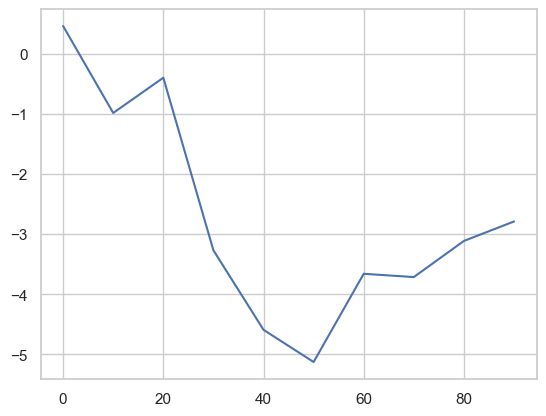

In [22]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s.plot();

Series 的索引会自动传给 Matplotlib 作为 X 轴。  
DataFrame 的 `plot()` 方法也支持多列一起绘图。

### Pandas `plot()` 常用参数

| 参数 | 说明 |
|---|---|
| `kind` | 图表类型，如 `"line"`、`"bar"`、`"hist"` |
| `use_index` | 是否使用索引作为 X 轴 |
| `title` | 图表标题 |
| `grid` | 是否显示网格 |
| `xlim`, `ylim` | 坐标轴范围 |
| `figsize` | 图表尺寸 |


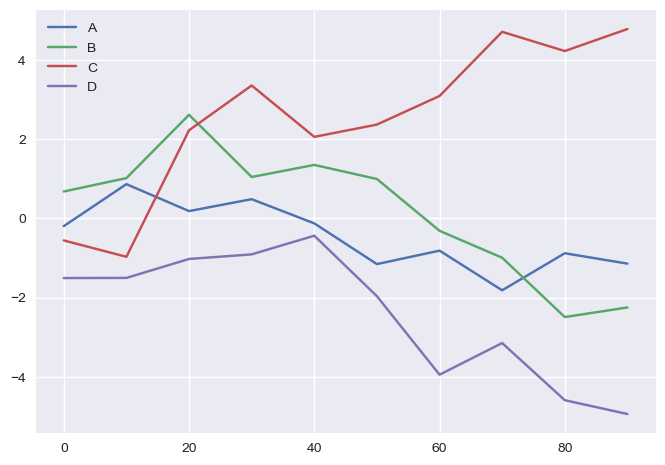

In [23]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns=["A", "B", "C", "D"],
                  index=np.arange(0, 100, 10))
plt.style.use('seaborn-v0_8')
df.plot();

In [24]:
# 查看所有可用的样式
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

### 3.1 柱状图

`plot.bar()` 和 `plot.barh()` 分别绘制垂直和水平柱状图。  
柱状图适合比较不同类别的数值。


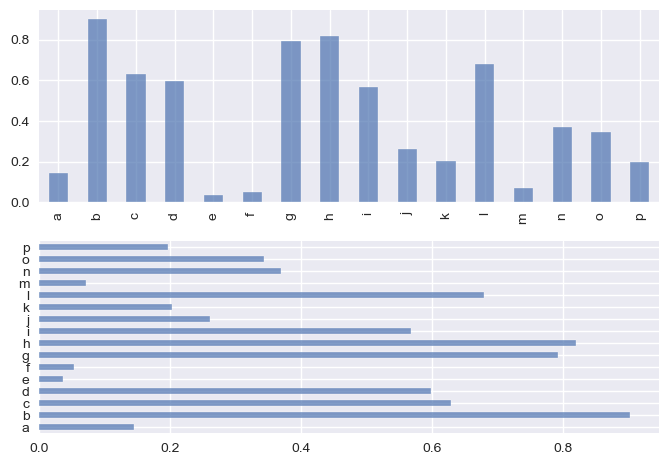

In [25]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], alpha=0.7) # color="k", 
data.plot.barh(ax=axes[1], alpha=0.7); # color="k", 

`alpha` 可以控制透明度。  
对于 DataFrame，柱状图会把每一行的数据作为一组并排显示。


In [26]:
np.random.seed(12348)

In [27]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                  columns=pd.Index(["A", "B", "C", "D"], name="Genus"))
df

Genus,A,B,C,D
one,0.370670,0.602792,0.229159,0.486744
two,0.420082,0.571653,0.049024,0.880592
three,0.814568,0.277160,0.880316,0.431326
four,0.374020,0.899420,0.460304,0.100843
five,0.433270,0.125107,0.494675,0.961825
six,0.601648,0.478576,0.205690,0.560547


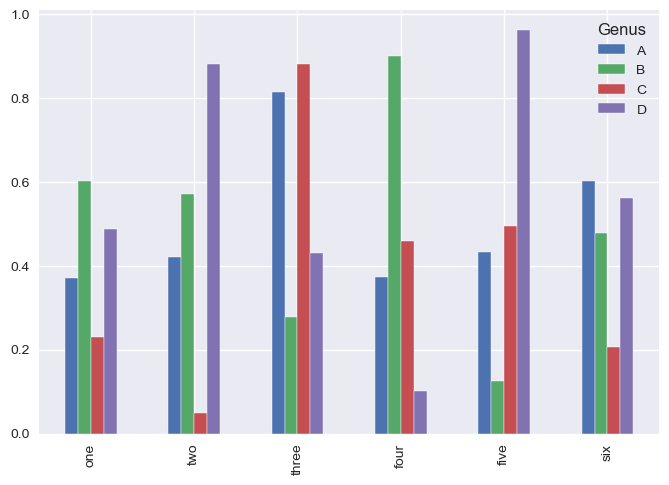

In [28]:
df.plot.bar();

如果设置 `stacked=True`，可以生成堆积柱状图。  
堆积柱状图适合展示总量及其组成。


<Axes: >

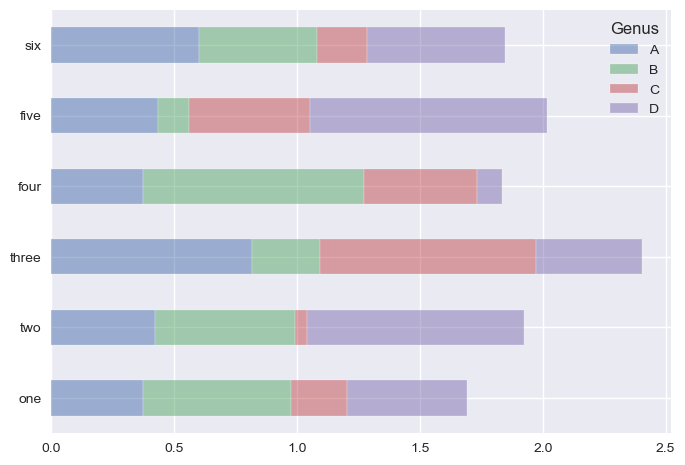

In [29]:
df.plot.barh(stacked=True, alpha=0.5)

下面使用小费数据示例，展示不同日期和聚会规模的比例分布。  
先读取数据，然后创建交叉表。


In [30]:
tips = pd.read_csv("examples/tips.csv")
party_counts = pd.crosstab(tips["day"], tips["size"])
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,5,32,15,9,8,3
Fri,3,32,10,8,4,0
Sat,3,49,25,19,4,6
Sun,5,21,16,12,10,1


In [31]:
party_counts = party_counts.loc[:, 2:5]

# Normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(axis="columns"),
                              axis="index")
party_pcts

size,2,3,4,5
day,,,,
Thur,0.500000,0.234375,0.140625,0.125000
Fri,0.592593,0.185185,0.148148,0.074074
Sat,0.505155,0.257732,0.195876,0.041237
Sun,0.355932,0.271186,0.203390,0.169492


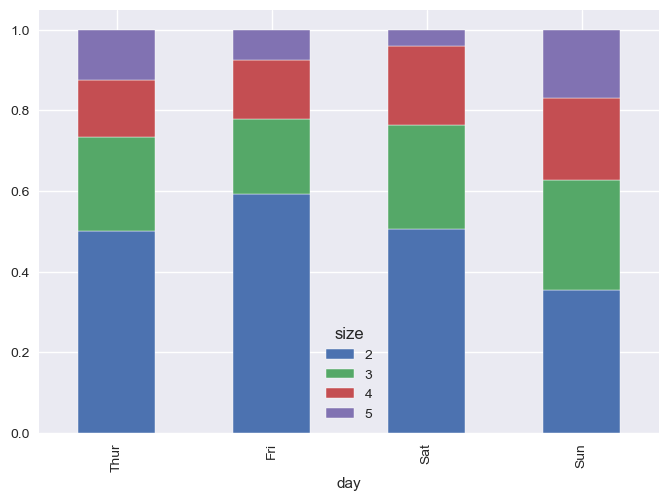

In [32]:
party_pcts.plot.bar(stacked=True);

### <font color='darkorange'><b>动手练习 2</b></font>

#### 题目
请使用 Pandas 绘图完成：

1. 创建一个包含 4 个类别和 3 个数值列的 DataFrame
2. 绘制并排柱状图
3. 绘制堆积柱状图

#### 你的答案
请在下方代码单元中完成练习。


In [33]:
# Write your code here



#### 参考答案

<details>
<summary>点击查看示例代码</summary>

```python
sales = pd.DataFrame({
    "Q1": [10, 15, 12, 18],
    "Q2": [14, 13, 17, 20],
    "Q3": [16, 18, 15, 22]
}, index=["A", "B", "C", "D"])

sales.plot.bar(title="Grouped Bar Chart")
sales.plot.bar(stacked=True, title="Stacked Bar Chart")
```

</details>


从图中可以观察不同日期的聚会规模分布。  
对于需要先汇总再绘图的任务，Seaborn 可以减少手工处理步骤。


In [34]:
import seaborn as sns

tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,43.40,5.79,Yes,Sun,Dinner,5,0.153948
1,21.22,2.81,Yes,Sun,Dinner,3,0.152634
2,30.97,4.13,Yes,Fri,Lunch,2,0.153875
3,38.88,8.00,No,Thur,Dinner,3,0.259067
4,12.68,1.08,No,Sun,Dinner,4,0.093103


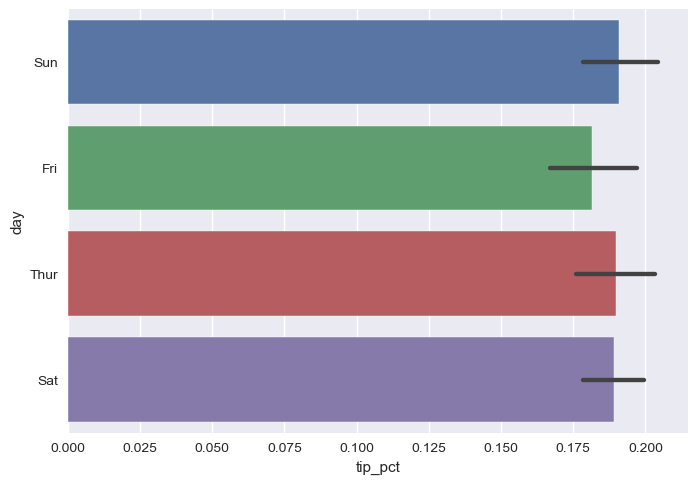

In [35]:
sns.barplot(x="tip_pct", y="day", data=tips, orient="h");

Seaborn 的绘图函数通常使用 `data` 参数接收 DataFrame，并用列名指定变量。  
柱状图默认显示均值，并可以绘制置信区间。


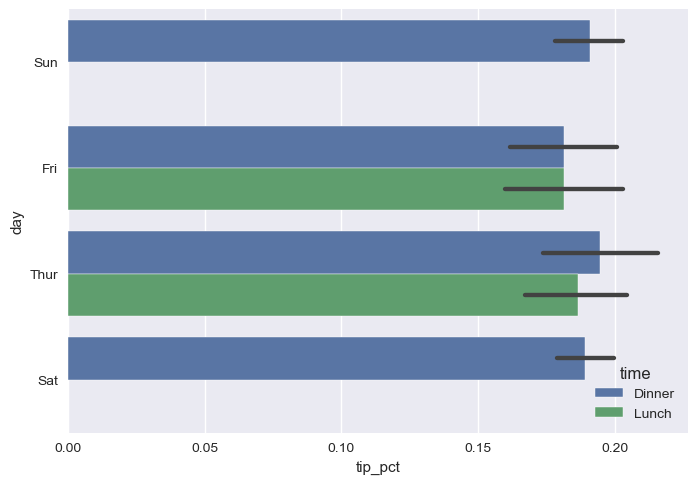

In [36]:
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h");

Seaborn 会自动设置较美观的主题。  
也可以使用 `sns.set_style()` 或 `sns.set_theme()` 调整风格。


In [37]:
# There are five preset seaborn themes: darkgrid, whitegrid, dark, white, and ticks.
sns.set_style("whitegrid")

### 3.2 直方图和密度图

直方图用于观察数值变量的分布。  
它会把连续数据划分为若干区间，并统计每个区间中的样本数量。


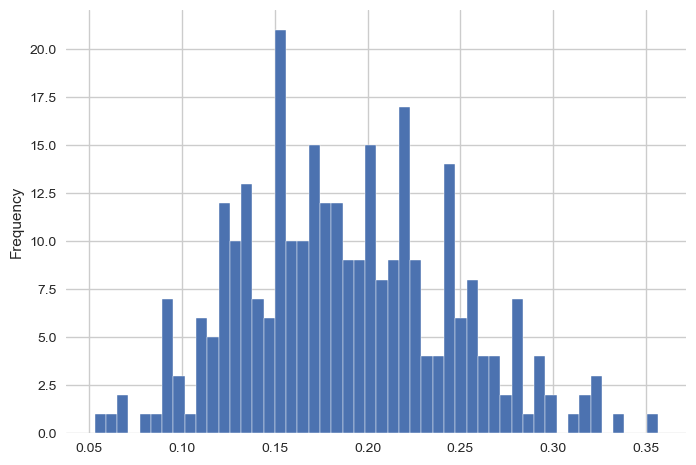

In [38]:
tips["tip_pct"].plot.hist(bins=50);

密度图，也叫 KDE 图，用平滑曲线估计连续变量的分布形状。

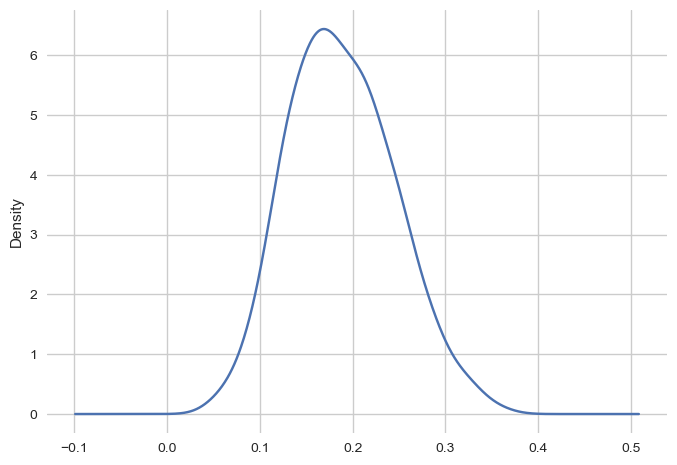

In [39]:
tips["tip_pct"].plot.density();

Seaborn 的 `distplot()` 已被弃用。  
现代写法可以使用 `histplot(..., kde=True)` 同时绘制直方图和密度曲线。


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


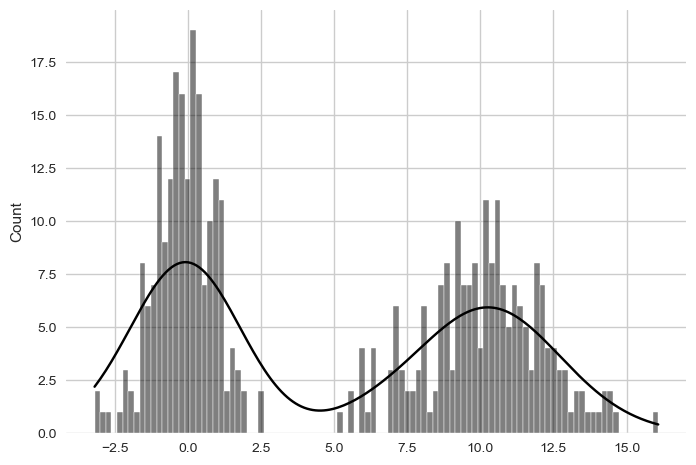

In [40]:
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)
values = pd.Series(np.concatenate([comp1, comp2]))

sns.histplot(values, bins=100, kde=True, color="black");


### 3.3 散点图或点图

散点图适合观察两个数值变量之间的关系。  
下面读取宏观经济示例数据，并计算若干变量的对数差分。


In [41]:
macro = pd.read_csv("examples/macrodata.csv")
data = macro[["cpi", "m1", "tbilrate", "unemp"]]
trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
115,0.004256,0.009235,-0.163269,0.198591
116,0.014193,0.008823,0.843449,-0.199897
117,0.007308,0.014746,-0.321623,0.280556
118,0.004015,0.009980,-0.187661,-0.338445
119,0.002924,0.007604,0.133609,0.239873


Seaborn 的 `regplot()` 可以绘制散点图，并添加线性回归趋势线。

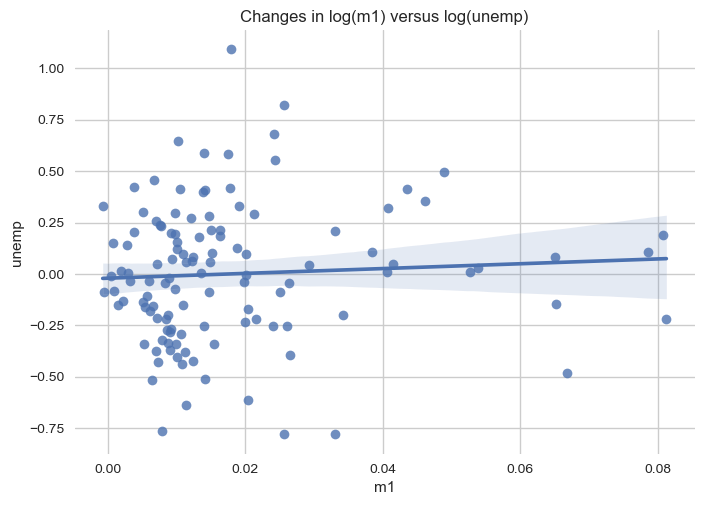

In [42]:
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(m1) versus log(unemp)");

如果想同时观察多个变量两两之间的关系，可以使用散点图矩阵。  
Seaborn 的 `pairplot()` 可以快速完成这一任务。


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

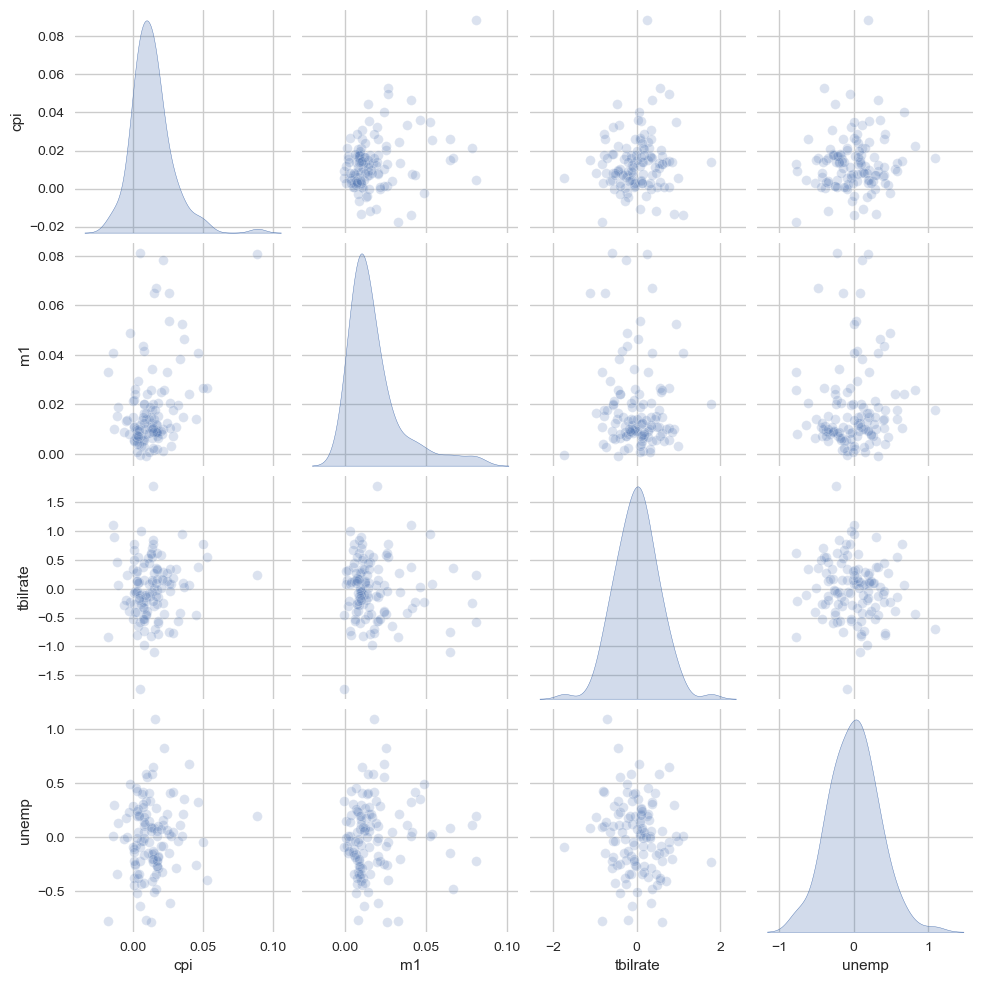

In [43]:
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2});

### 3.4 分面网格和分类数据

当数据中存在多个分类变量时，分面图可以把不同子集分别画在不同小图中。  
Seaborn 的 `catplot()` 支持按行、列、颜色等维度拆分数据。


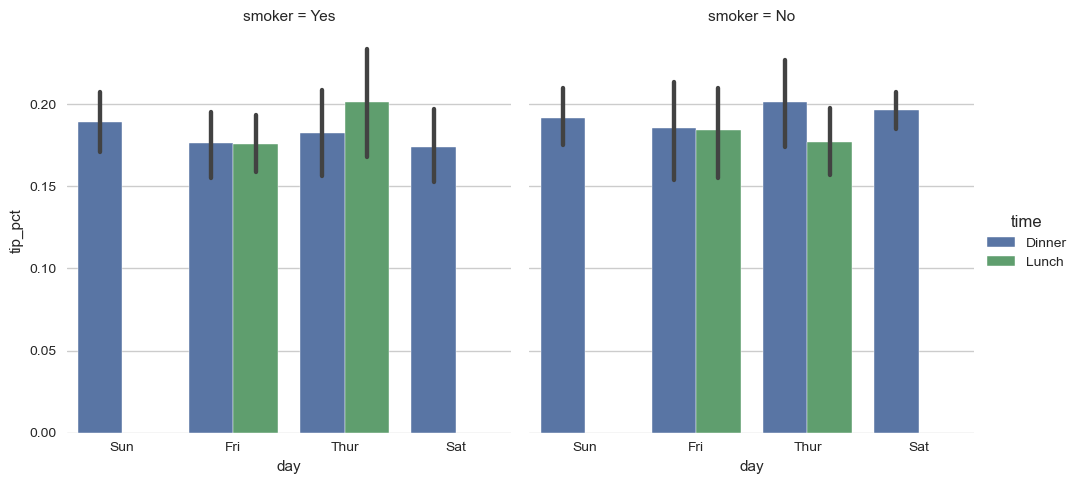

In [44]:
sns.catplot(x="day", y="tip_pct", hue="time", col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1]);

除了按颜色分组，还可以把某个分类变量放到行方向，形成更多分面。

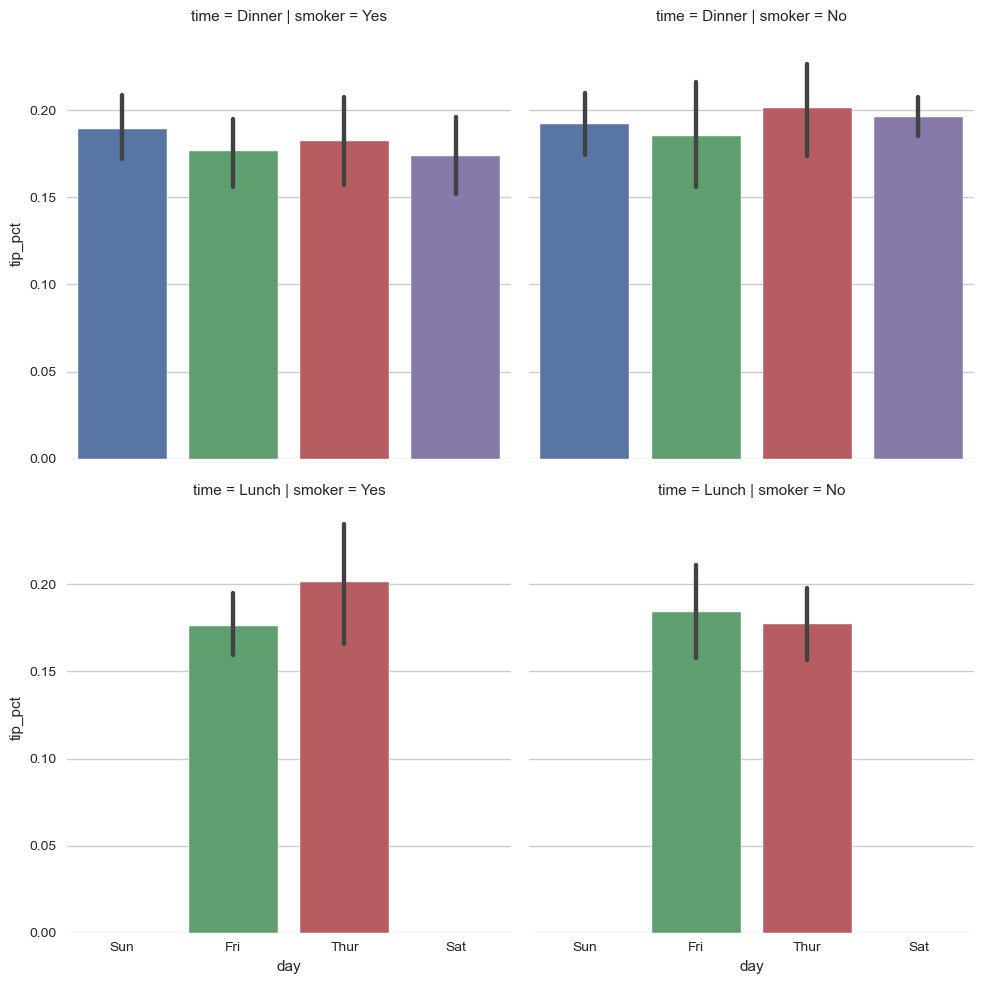

In [45]:
sns.catplot(x="day", y="tip_pct", row="time",
            col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1]);

`catplot()` 还支持其他图形类型。  
例如箱线图可以显示中位数、四分位数和异常值。


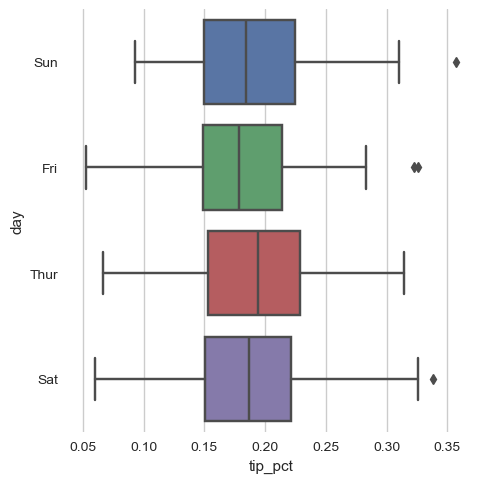

In [46]:
sns.catplot(x="tip_pct", y="day", kind="box",
            data=tips[tips.tip_pct < 0.5]);

### <font color='darkorange'><b>动手练习 3</b></font>

#### 题目
请使用 Seaborn 对 `tips` 数据完成：

1. 读取 `examples/tips.csv`
2. 计算 `tip_pct`
3. 用 `sns.boxplot()` 绘制不同日期的小费比例箱线图
4. 用 `sns.scatterplot()` 绘制 `total_bill` 与 `tip_pct` 的关系

#### 你的答案
请在下方代码单元中完成练习。


In [47]:
# Write your code here



#### 参考答案

<details>
<summary>点击查看示例代码</summary>

```python
tips_practice = pd.read_csv("examples/tips.csv")
tips_practice["tip_pct"] = tips_practice["tip"] / tips_practice["total_bill"]

sns.boxplot(x="day", y="tip_pct", data=tips_practice)
plt.figure()
sns.scatterplot(x="total_bill", y="tip_pct", data=tips_practice)
```

</details>


## 课堂小结

在本讲中，我们学习了 Python 数据分析中的基础可视化方法。

| 知识点 | 主要内容 |
|---|---|
| **Matplotlib 基础** | `Figure`、`Axes`、`subplot` |
| **创建子图** | `plt.figure()`、`fig.add_subplot()`、`plt.subplots()` |
| **线图设置** | 颜色、线型、标记、`drawstyle` |
| **图表修饰** | 标题、坐标轴标签、刻度、图例 |
| **注解** | `ax.annotate()` |
| **图形对象** | Rectangle、Circle、Polygon |
| **保存图表** | `savefig()` |
| **Pandas 绘图** | `Series.plot()`、`DataFrame.plot()` |
| **柱状图** | `plot.bar()`、`plot.barh()` |
| **分布图** | 直方图、密度图、`histplot()` |
| **关系图** | `regplot()`、`pairplot()` |
| **分类与分面图** | `catplot()` |


### <font color='cornflowerblue'><b>思考题</b></font>

什么时候应该使用 Matplotlib，什么时候应该使用 Pandas 或 Seaborn？

#### 参考答案

<details>
<summary>点击查看解释</summary>

- 如果需要精细控制图表元素，例如坐标轴、注解、子图布局，适合使用 Matplotlib
- 如果只是快速查看 Series 或 DataFrame 的趋势和分布，适合使用 Pandas 绘图
- 如果需要绘制统计图形，例如分类均值、分布、回归线、分面图，适合使用 Seaborn

实际项目中，经常先用 Pandas 或 Seaborn 快速绘图，再用 Matplotlib 做细节调整。

</details>


<div class="alert alert-success">

**进一步学习资源**

- Matplotlib 速查表（Cheat Sheet）：https://matplotlib.org/cheatsheets/
- Python for Data Science 速查表（Cheat Sheet）：https://github.com/jramshur/Coding-Cheat-Sheets/tree/master

</div>

---

*本节课到此结束，感谢大家的学习！如有疑问，请随时提问。*